# Previous Material: Not Assigned

This notebook uses another textbook's chapter numbering. It is retained for review, not assigned reading for the current course. Its chapter, week, and examination labels are historical and do not define current requirements. Use the current course syllabus and its first-meeting notebook links.


# Chapter 7: Relational Database Design and Normalization


## Core Question

Which facts are stored repeatedly, can a decomposition reconstruct the original relation
without false rows, and does every important determinant identify a complete row?

Use this guide with the executable SQL lab cell. Predict before executing, and do not infer a
business rule from one convenient sample instance.


## Scope and Connection

Chapter 6 mapped requirements to relations. This chapter is useful when an existing table,
spreadsheet, or mixed design still combines several kinds of facts.

The classroom core is anomalies, functional dependencies, attribute closure, binary
lossless decomposition, spurious tuples, and introductory 3NF/BCNF decisions. Canonical
covers and complete decomposition algorithms are extensions.


## Teaching Summary

| Topic | Worked example and practice | Evidence to retain |
|---|---|---|
| Anomalies and dependencies | Flattened course facts | Business rule and counterexample |
| Attribute closure | Candidate-key calculation | Closure steps and minimality check |
| Lossless decomposition | Reconstructing normalized relations | Both difference checks |
| 3NF and BCNF | Small dependency sets | Determinant and key reasoning |


## Prerequisites

- Relations, tuples, candidate keys, and foreign keys.
- Projection and natural join.
- Basic schema and data-modification SQL.
- Chapter 6 entity, relationship, and mapping concepts.


## Learning Objectives

After completing this chapter, you should be able to:

1. Identify update, insertion, and deletion anomalies.
2. Write a functional dependency from a stable business rule.
3. Reject an unsupported dependency with a counterexample.
4. Calculate a small attribute closure and test key minimality.
5. Test a binary decomposition for losslessness and identify spurious tuples.
6. Apply introductory BCNF and 3NF criteria.
7. Explain a basic tradeoff involving BCNF and dependency preservation.


## 1. Mixed Facts and Anomalies

Consider:

```text
course_enrollment_record(
  student_id, student_name, dept_code, dept_name,
  course_id, course_title, credits, grade
)
```

Business rules imply:

```text
student_id -> student_name, dept_code
dept_code  -> dept_name
course_id  -> course_title, credits
(student_id, course_id) -> grade
```

This relation stores Student, Department, Course, and Enrollment facts together.

- **Update anomaly:** changing one repeated department name can create inconsistent copies.
- **Insertion anomaly:** a course with no enrollment cannot be stored naturally.
- **Deletion anomaly:** deleting the last enrollment in a course can remove the only copy
  of that course's title and credits.

The problem is not the number of columns. It is the dependency structure and the resulting
operations.


### Running the Small Examples

Run this setup cell once. Each small SQL example starts from its displayed input tables in a fresh in-memory SQLite database and closes it afterward. The table definitions and SQL are supplied; Python helper syntax is not an additional learning requirement. Read and predict before running each example. The larger chapter lab remains available later in this notebook. The instructor will select variations for class practice; the additional examples are not separate required assignments.


In [1]:
import sqlite3


def run_small_example(tables, statements):
    """Start with the displayed input again each time; keep no database file."""
    db = sqlite3.connect(":memory:", isolation_level=None)
    db.execute("PRAGMA foreign_keys = ON")
    try:
        for name, definition, rows in tables:
            db.execute(f"CREATE TABLE {name} ({definition})")
            if rows:
                marks = ", ".join("?" for _ in rows[0])
                db.executemany(f"INSERT INTO {name} VALUES ({marks})", rows)
        for label, sql in statements:
            print(label)
            try:
                cursor = db.execute(sql)
                if cursor.description:
                    print(" | ".join(column[0] for column in cursor.description))
                    rows = cursor.fetchall()
                    for row in rows:
                        print(" | ".join("NULL" if value is None else str(value) for value in row))
                    if not rows:
                        print("(no rows)")
                else:
                    print("Statement completed.")
            except sqlite3.IntegrityError:
                print("IntegrityError: the statement was rejected.")
            print()
    finally:
        db.close()


### Small Example: Deleting an enrollment can erase a course fact

An enrollment row and a course description are different facts. When only one mixed row contains a course's description, deleting the enrollment also removes that description.

The following data are artificial teaching inputs, not student records.

**Input: flat**

| student | course | title |
| --- | --- | --- |
| S1 | DB | Database |
| S2 | DB | Database |
| S1 | WEB | Web Design |

**Predict before checking.** After deleting S1's WEB enrollment, can this table still tell us WEB's title?


In [2]:
tables = [('flat',
  'student TEXT, course TEXT, title TEXT',
  [['S1', 'DB', 'Database'], ['S2', 'DB', 'Database'], ['S1', 'WEB', 'Web Design']])]
statements = [
    ('Delete enrollment', """
DELETE FROM flat WHERE student='S1' AND course='WEB'
"""),
    ('Remaining course facts', """
SELECT DISTINCT course,title FROM flat ORDER BY course
"""),
]
run_small_example(tables, statements)


Delete enrollment
Statement completed.

Remaining course facts
course | title
DB | Database



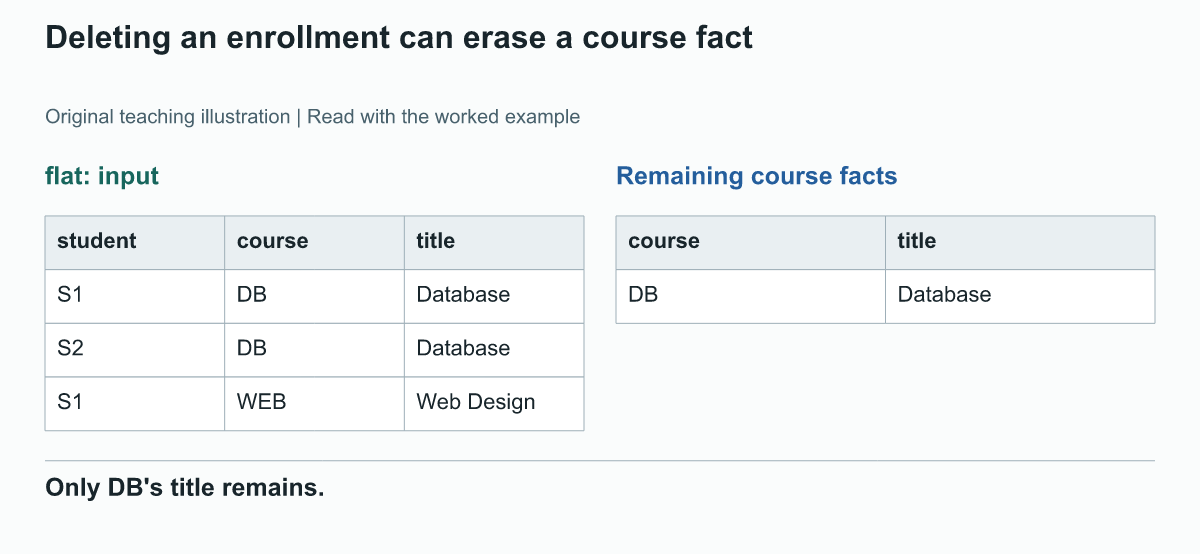


**Read the result.** Only DB's title remains. WEB may still be a valid course, but the mixed table lost its only description. A separate Course relation allows deletion of an enrollment without deleting the course fact.

**Try a change.** Identify the insertion problem for a new course with no student, and the update problem when only one DB title copy is renamed.

**Check your reasoning.** For each anomaly, name the valid fact that is lost, impossible to insert naturally, or made inconsistent.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Practice

For `employee_project(employee_id, employee_name, project_id, project_name, hours)`,
identify Employee, Project, and assignment facts and one anomaly of each applicable type.


## 2. Functional Dependencies

For schema R, `alpha -> beta` means that every legal pair of tuples that agrees on all
attributes in alpha must also agree on beta. Alpha is the determinant.

A dependency such as `(student_id, course_id) -> student_id` is trivial because the right
side is included in the left. If `K -> R`, K is a superkey; if K is minimal, it is a
candidate key.


### Small Example: Two rows can disprove a proposed dependency

X determines Y when every legal pair agreeing on X also agrees on Y. A single counterexample can disprove a proposed rule; a convenient sample cannot establish that the rule holds in every future state.

The following data are artificial teaching inputs, not student records.

**Input: registration**

| student | course |
| --- | --- |
| S1 | DB |
| S1 | WEB |
| S2 | DB |

**Predict before checking.** Does this instance satisfy student -> course? Which two rows decide the answer?


In [3]:
tables = [('registration',
  'student TEXT, course TEXT',
  [['S1', 'DB'], ['S1', 'WEB'], ['S2', 'DB']])]
statements = [
    ('Conflicting course values', """
SELECT student,COUNT(DISTINCT course) AS different_courses FROM registration GROUP BY student HAVING COUNT(DISTINCT course)>1 ORDER BY student
"""),
]
run_small_example(tables, statements)


Conflicting course values
student | different_courses
S1 | 2



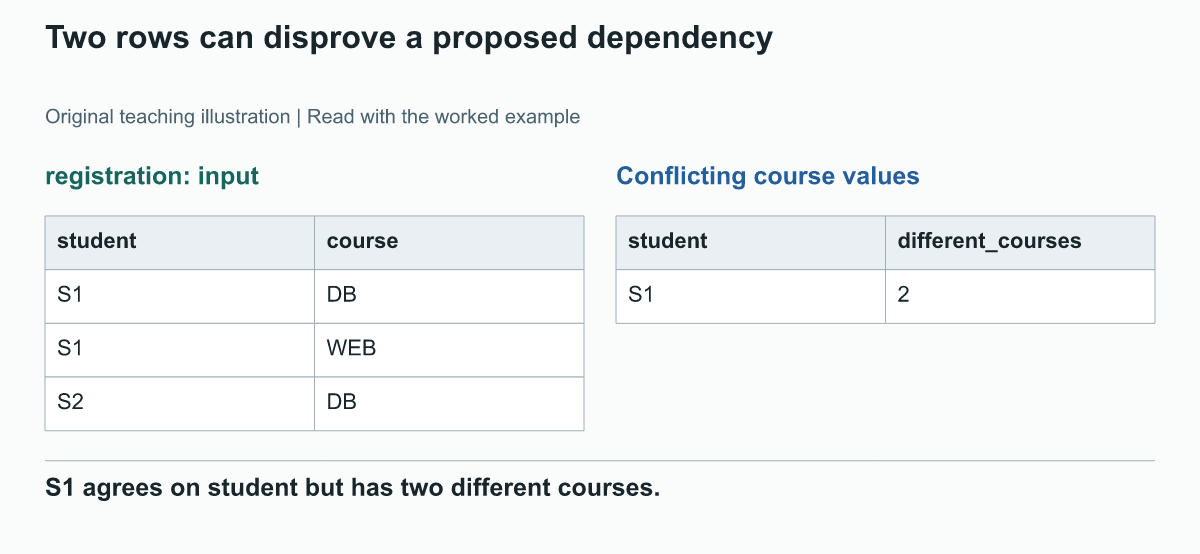


**Read the result.** S1 agrees on student but has two different courses. That pair violates student -> course. Removing one row would remove the counterexample, not prove a permanent one-course-per-student rule.

**Try a change.** Construct two legal courses with the same title to test the proposed dependency title -> course ID.

**Check your reasoning.** Write both rows and the supporting business permission. Distinguish disproof by a legal instance from a rule stated by requirements.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Rule and Counterexample

The rule "each student identifier represents one student" supports:

```text
student_id -> student_name, dept_code
```

It does not support `student_id -> course_id`. The legal rows `(S101, DB201)` and
`(S101, FT210)` form a counterexample.

Practice: decide whether `course_title -> course_id` is supported. Either state a rule
that guarantees unique titles or provide two legal courses with one title and different
identifiers.


## 3. Attribute Closure and Candidate Keys

The closure `alpha+` contains every attribute functionally determined by alpha. Start with
alpha, repeatedly apply dependencies whose left sides are already present, and stop when
no new attribute can be added.

For `{student_id, course_id}`:

1. Begin with both identifiers.
2. Add student name and department code from `student_id`.
3. Add department name from department code.
4. Add course title and credits from `course_id`.
5. Add grade from the identifier pair.

The closure contains every attribute, so the pair is a superkey. Removing either
identifier prevents determination of the other entity's facts and grade, so the pair is
minimal and is therefore a candidate key.


### Grow the closure from the two identifiers

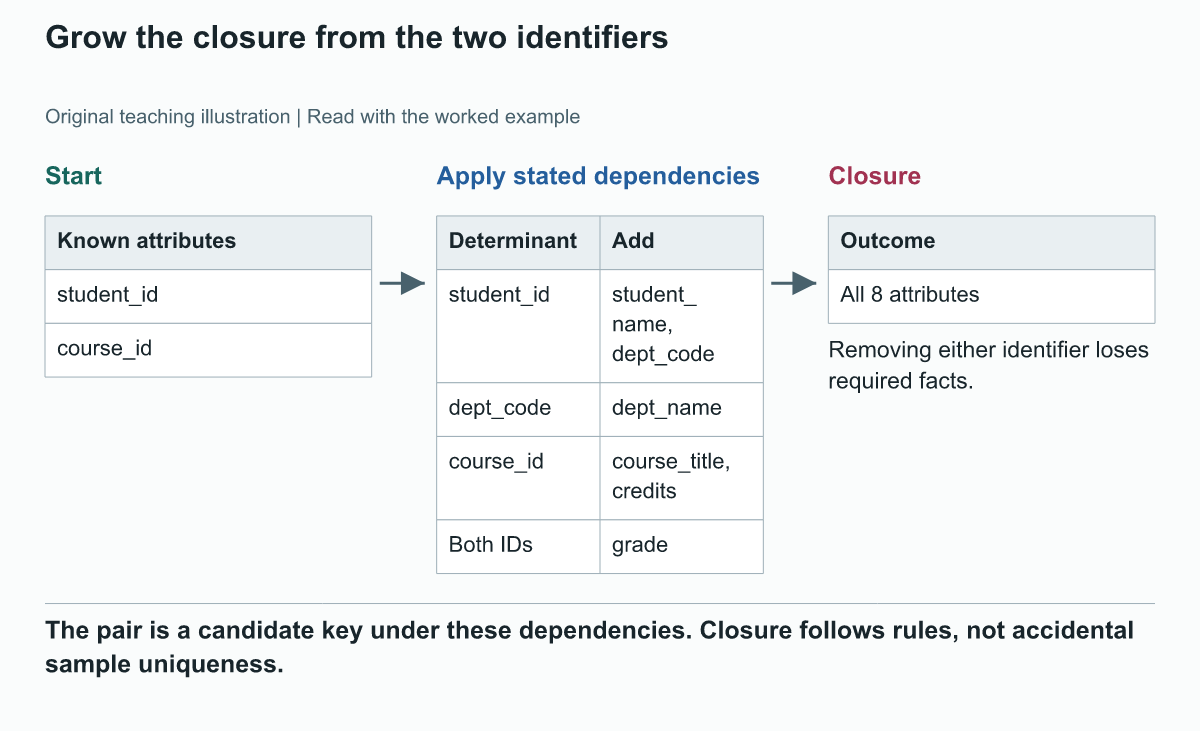

The pair is a candidate key under these dependencies. Closure follows rules, not accidental sample uniqueness.


### Small Example: Follow dependencies until no new attribute appears

A closure is the set of attributes determined by the starting attributes under the stated dependencies. Test minimality by removing each proposed key component, not by counting unique rows in a sample.

The following data are artificial teaching inputs, not student records.

**Input: dependencies**

| left side | right side |
| --- | --- |
| employee | name |
| project | title |
| employee, project | hours |

**Predict before checking.** Starting with employee and project, can you reach every attribute? What is missing from employee alone?


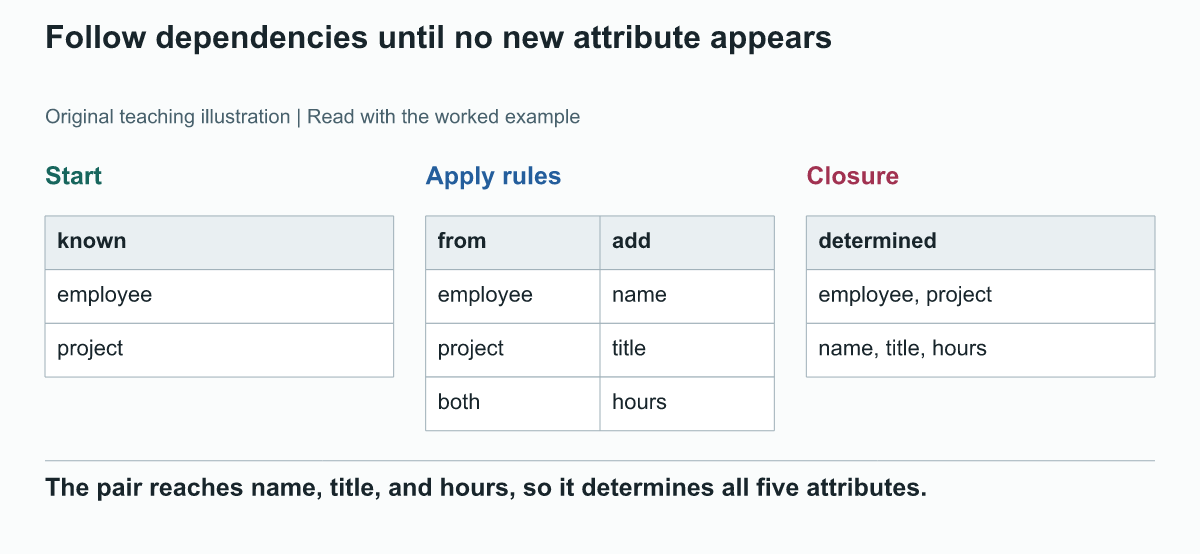


**Read the result.** The pair reaches name, title, and hours, so it determines all five attributes. Employee alone cannot reach project, title, or hours. Project alone cannot reach employee, name, or hours. Therefore the pair is a candidate key under exactly these dependencies.

**Try a change.** Add the rule project -> employee and recompute the candidate key. Record the closure steps, not just the final key.

**Check your reasoning.** A newly added dependency can change the key. State the full rule set used for each conclusion.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Practice

Given:

```text
employee_id -> employee_name
project_id -> project_name
(employee_id, project_id) -> hours
```

Calculate `{employee_id, project_id}+` and test both single-attribute removals.


## 4. Lossless Decomposition

A decomposition is lossless if projecting a legal relation into the new schemas and
joining the projections reconstructs exactly the original relation.

For a binary decomposition R into R1 and R2 under functional dependencies, the step is
lossless when the common attributes determine all attributes of R1 or all attributes of
R2:

```text
(R1 intersection R2) -> R1
or
(R1 intersection R2) -> R2
```

Having a shared column is not enough; the shared attributes must identify one side.


### Joining on a non-key name invents false combinations

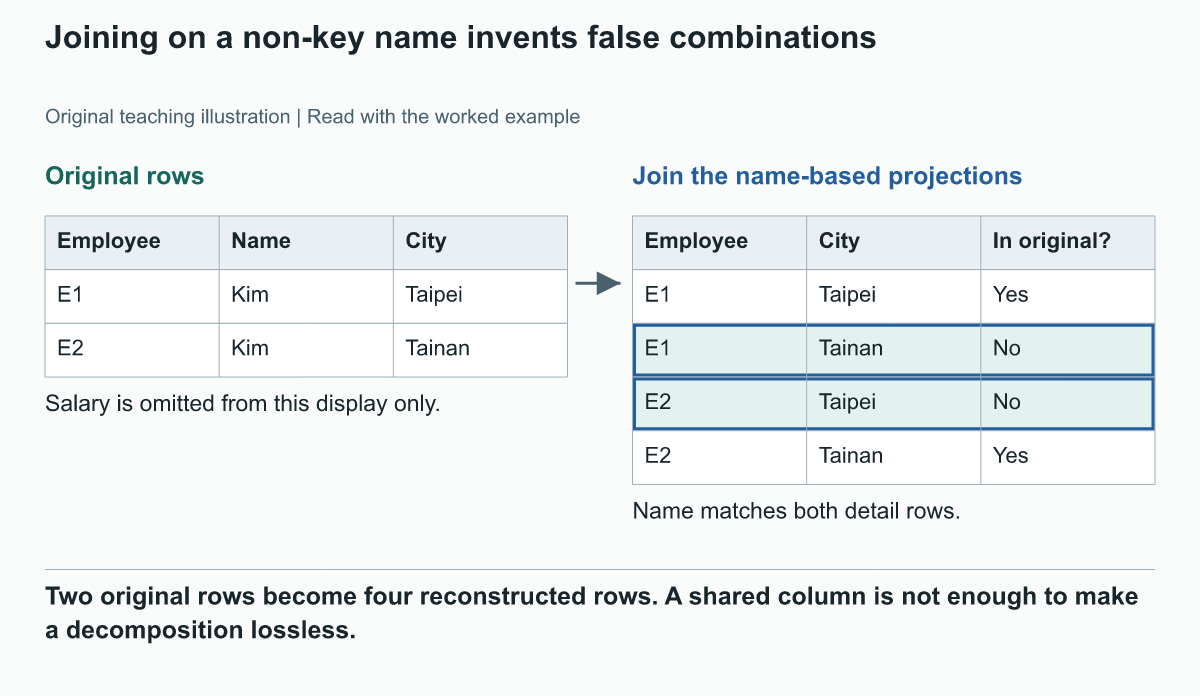

Two original rows become four reconstructed rows. A shared column is not enough to make a decomposition lossless.


### Small Example: A shared department key reconstructs the same facts

For a binary decomposition under functional dependencies, a sufficient and necessary lossless-join condition is that the shared attributes determine one whole side. Sample reconstruction checks illustrate the result; the dependency supplies the general reason.

The following data are artificial teaching inputs, not student records.

**Input: flat**

| student | dept | name |
| --- | --- | --- |
| S1 | IM | Information |
| S2 | IM | Information |
| S3 | FN | Finance |

**Predict before checking.** Will projecting Student(student,dept) and Department(dept,name) and joining them create a new combination under dept -> name?


In [4]:
tables = [('flat',
  'student TEXT, dept TEXT, name TEXT',
  [['S1', 'IM', 'Information'], ['S2', 'IM', 'Information'], ['S3', 'FN', 'Finance']])]
statements = [
    ('Reconstructed', """
WITH s AS (SELECT DISTINCT student,dept FROM flat), d AS (SELECT DISTINCT dept,name FROM flat) SELECT s.student,s.dept,d.name FROM s JOIN d USING(dept) ORDER BY s.student
"""),
]
run_small_example(tables, statements)


Reconstructed
student | dept | name
S1 | IM | Information
S2 | IM | Information
S3 | FN | Finance



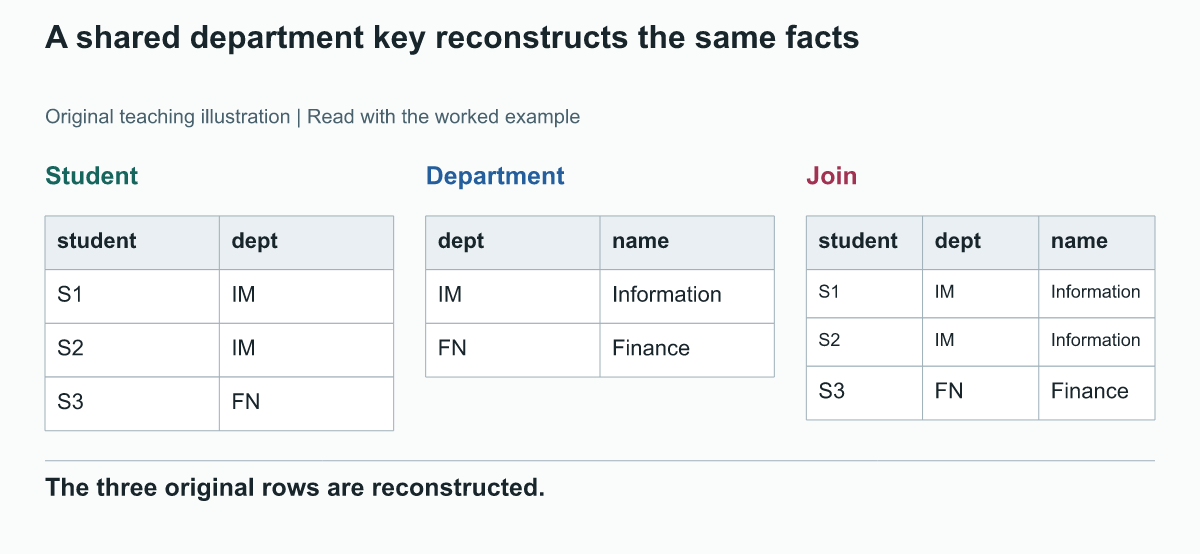


**Read the result.** The three original rows are reconstructed. The shared dept determines the Department side because each code has one name. This is the reason the decomposition is lossless for legal data under that dependency.

**Try a change.** Explain why replacing the shared key with a nonunique person name fails in the Kim example below. Retain the extra reconstructed pairs.

**Check your reasoning.** Distinguish a dependency argument from a test of only three rows.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### Lossless Example

Split Department from the flattened relation:

```text
Department(dept_code, dept_name)
Remaining(student_id, student_name, dept_code,
          course_id, course_title, credits, grade)
```

The common attribute `dept_code` determines Department, so this step is lossless. Further
steps produce Department, Student, Course, and Enrollment relations. The lab uses
bidirectional `EXCEPT` checks for the supplied instance.


### Lossy Example

Original rows:

```text
(E1, Kim, Taipei, 60000)
(E2, Kim, Tainan, 62000)
```

Split into `EmployeeIdentity(employee_id, name)` and
`EmployeeDetails(name, city, salary)`. Name is not a key. Joining the projections produces
four rows, including two false employee-city combinations.


### Practice

Run the lossless and lossy lab sections. Retain both difference counts for the lossless
case and identify the two spurious Kim rows in the lossy case.


## 5. Boyce-Codd Normal Form

R is in BCNF when every nontrivial dependency `alpha -> beta` has a determinant alpha
that is a superkey.

In the flattened relation, `dept_code -> dept_name` is nontrivial, but department code
does not determine Student, Course, and Enrollment facts. This is a BCNF violation.

After decomposition:

- Department has key determinant `dept_code`.
- Student has key determinant `student_id`.
- Course has key determinant `course_id`.
- Enrollment has key determinant `(student_id, course_id)`.

Under the listed rules, each relation satisfies BCNF. A new business rule requires a new
check.


### Small Example: Ask whether the determinant identifies the entire row

BCNF requires a superkey on the left of every nontrivial dependency. A determinant may identify a department fact without identifying the whole mixed enrollment row.

The following data are artificial teaching inputs, not student records.

**Input: rules**

| relation | dependency |
| --- | --- |
| Mixed(student,dept,name) | student -> dept; dept -> name |
| Department(dept,name) | dept -> name |

**Predict before checking.** In which relation does dept determine every attribute?


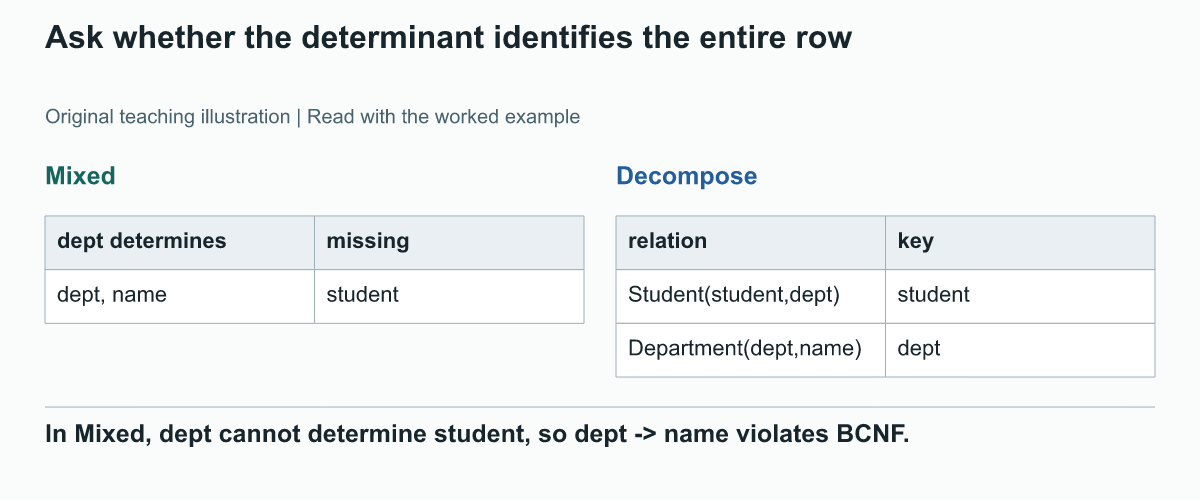


**Read the result.** In Mixed, dept cannot determine student, so dept -> name violates BCNF. In Department, dept determines both attributes and is a key. The same dependency has a different consequence when the relation schema changes.

**Try a change.** Give two students in one department to demonstrate why dept is not a key of Mixed. Then identify the key of Student(student,dept).

**Check your reasoning.** Use the relation's complete attribute set when deciding whether the determinant is a superkey.

When this variation is assigned, retain your prediction, result, and correction or explanation.


## 6. Third Normal Form

For every dependency `alpha -> beta`, 3NF allows the dependency when it is trivial, alpha
is a superkey, or each attribute in `beta - alpha` is prime. A prime attribute occurs in
at least one candidate key. Every BCNF relation is in 3NF, but not every 3NF relation is
in BCNF.


### Small Example: A prime attribute explains the 3NF exception

A prime attribute belongs to at least one candidate key. For a nontrivial dependency, 3NF permits a non-superkey determinant when each remaining right-side attribute is prime. BCNF does not have that exception.

The following data are artificial teaching inputs, not student records.

**Input: rules**

| left side | right side |
| --- | --- |
| student, course | teacher |
| teacher | course |

**Predict before checking.** Given the keys (student,course) and (student,teacher), is course prime? Is teacher alone a superkey?


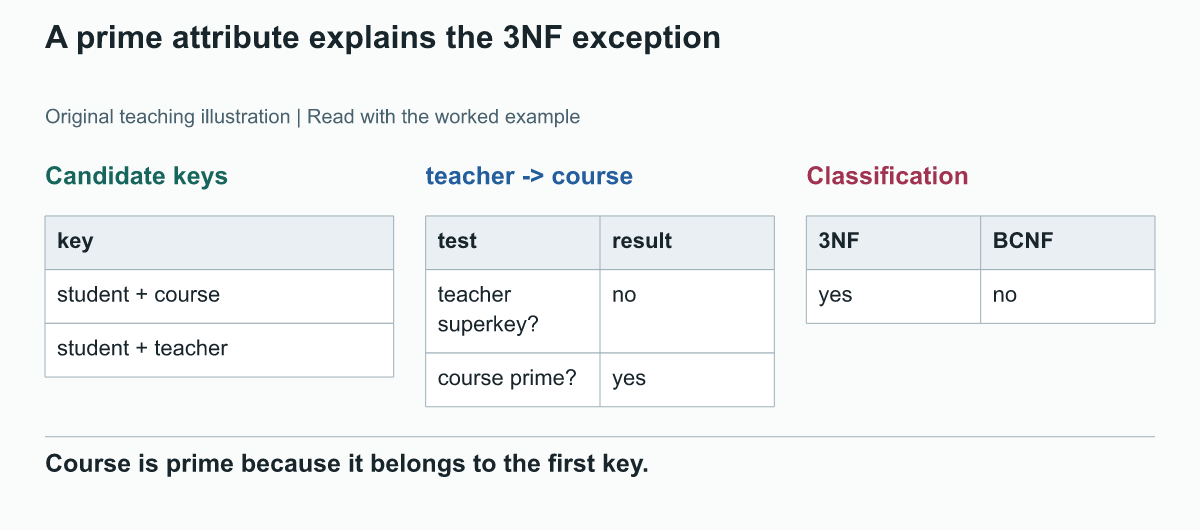


**Read the result.** Course is prime because it belongs to the first key. Teacher alone cannot determine student, so it is not a superkey. Thus teacher -> course violates BCNF but meets the 3NF prime-attribute condition under these dependencies.

**Try a change.** Show how each stated pair reaches all three attributes, then remove one component from each pair to test minimality.

**Check your reasoning.** Use both candidate keys. Checking only a chosen primary key can miss prime attributes.

When this variation is assigned, retain your prediction, result, and correction or explanation.


### 3NF but Not BCNF Example

```text
TeachingAssignment(student_id, course_id, instructor_id)

(student_id, course_id) -> instructor_id
instructor_id -> course_id
```

If every instructor teaches only one course, candidate keys are
`(student_id, course_id)` and `(student_id, instructor_id)`. All three attributes are
prime. `instructor_id -> course_id` violates BCNF because instructor ID is not a superkey,
but it satisfies the prime-attribute allowance in 3NF.

If instructors may teach several courses, the second dependency no longer holds and the
normal-form analysis changes. Normal form is a property of a schema together with its
valid dependencies.


## 7. Dependency Preservation as a Tradeoff

A dependency-preserving decomposition allows each original dependency to be checked in
individual decomposed relations without joining them.

Splitting TeachingAssignment into
`InstructorCourse(instructor_id, course_id)` and
`StudentInstructor(student_id, instructor_id)` can be lossless and BCNF under the stated
rule. However, the original dependency
`(student_id, course_id) -> instructor_id` is not contained in one relation and cannot be
checked with one local key constraint.

This example shows why a design discussion should include redundancy, losslessness,
dependency enforcement, and implementation cost rather than stopping after the label
BCNF.


## Common Errors

1. Guessing a dependency from a small sample without a business rule.
2. Treating current uniqueness as proof of a candidate key.
3. Listing decomposed tables without anomalies, dependencies, or a lossless argument.
4. Assuming that any shared attribute makes a join lossless.
5. Applying a simplified 3NF slogan without finding keys and prime attributes.
6. Assuming that BCNF always preserves every dependency.
7. Treating one successful sample join as proof for every legal instance.


## Classroom and Individual Evidence

Compare a 3NF single relation with a BCNF decomposition using the same four criteria:
repetition, losslessness, local dependency checking, and implementation cost.

Submit the original relation and rules, dependencies and key closure, one anomaly, the
decomposition and lossless reason, normal-form decisions, and one revision made after
feedback.


## Chapter Summary

Normalization converts business rules into functional dependencies and uses closure,
lossless decomposition, and normal-form criteria to evaluate a schema. A good answer
preserves both data meaning and enforceable constraints. Chapter 14 moves to physical
design and query-plan evidence after the logical design is sound.


## After-Class Continuation

Repeat the sequence "rules, dependencies, anomalies, decomposition, lossless check" on a
real table. Armstrong's axioms, canonical covers, and complete decomposition algorithms
are extensions rather than Exam 2 operations.


## Build and Inspect the Chapter Database

The executable cells use SQLite through Python's standard `sqlite3` module. Follow the
cells in order:

1. Open a database connection and enable foreign-key enforcement.
2. Execute the chapter's `CREATE TABLE` statements before inserting rows.
3. Load the synthetic example data.
4. Inspect the resulting tables, columns, primary keys, and foreign keys.
5. Check referential integrity before running the chapter queries.
6. Predict each query result, execute it, and explain any difference.

`DATABASE_NAME` is initially `:memory:`. The database disappears when its connection
closes; closing a browser tab alone may leave the kernel and connection running.
Change it to a filename such as `chapter_database.db` when you want SQLite to create a
persistent database in the notebook's working directory. Do not switch to a persistent
file until the in-memory version runs successfully from top to bottom.


In [5]:
import sqlite3

print(f"Python {__import__('sys').version.split()[0]}; SQLite {sqlite3.sqlite_version}")
DATABASE_NAME = ":memory:"  # Change to "chapter_database.db" to keep a database file.
connection = sqlite3.connect(DATABASE_NAME, isolation_level=None)
connection.execute("PRAGMA foreign_keys = ON")


def run_sql_script(connection, script, max_rows=20):
    """Execute a SQLite script and display result-producing statements."""
    buffer = ""
    for raw_line in script.splitlines():
        stripped = raw_line.strip()
        if stripped.startswith(".print"):
            message = stripped[len(".print"):].strip().strip("\"'")
            print(f"\n{message}")
            continue
        buffer += raw_line + "\n"
        if not sqlite3.complete_statement(buffer):
            continue
        statement = buffer.strip()
        buffer = ""
        if not statement:
            continue
        cursor = connection.execute(statement)
        if cursor.description:
            columns = [column[0] for column in cursor.description]
            rows = cursor.fetchmany(max_rows + 1)
            print(" | ".join(columns))
            for row in rows[:max_rows]:
                print(" | ".join("NULL" if value is None else str(value) for value in row))
            if len(rows) > max_rows:
                print(f"... additional rows omitted after {max_rows}")
    remaining = "\n".join(
        line for line in buffer.splitlines() if not line.strip().startswith("--")
    ).strip()
    if remaining:
        raise ValueError("The embedded SQL ends with an incomplete statement.")


def inspect_database(connection):
    """Display tables, columns, primary keys, foreign keys, and integrity status."""
    tables = [
        row[0]
        for row in connection.execute(
            "SELECT name FROM sqlite_master WHERE type='table' AND name NOT LIKE 'sqlite_%' ORDER BY name"
        )
    ]
    print("Tables:", ", ".join(tables) if tables else "none")
    for table in tables:
        columns = connection.execute(f'PRAGMA table_info("{table}")').fetchall()
        primary_key = [row[1] for row in sorted(columns, key=lambda row: row[5]) if row[5]]
        print(f"\n{table}")
        print("  columns:", ", ".join(f"{row[1]} {row[2]}" for row in columns))
        print("  primary key:", ", ".join(primary_key) if primary_key else "none")
        for index_row in connection.execute(f'PRAGMA index_list("{table}")').fetchall():
            if index_row[2] and index_row[3] == "u":
                unique_columns = [
                    row[2]
                    for row in connection.execute(
                        f'PRAGMA index_info("{index_row[1]}")'
                    ).fetchall()
                ]
                print("  unique constraint:", ", ".join(unique_columns))
        foreign_keys = connection.execute(f'PRAGMA foreign_key_list("{table}")').fetchall()
        for foreign_key in foreign_keys:
            print(f"  foreign key: {foreign_key[3]} -> {foreign_key[2]}.{foreign_key[4]}")
    violations = connection.execute("PRAGMA foreign_key_check").fetchall()
    print("\nForeign-key check:", "PASS" if not violations else violations)


Python 3.12.9; SQLite 3.45.3


### Normalization lab


In [6]:
SQL_1 = """PRAGMA foreign_keys = ON;

DROP TABLE IF EXISTS ch07_enrollment;
DROP TABLE IF EXISTS ch07_course;
DROP TABLE IF EXISTS ch07_student;
DROP TABLE IF EXISTS ch07_department;
DROP TABLE IF EXISTS ch07_course_enrollment_record;
DROP TABLE IF EXISTS ch07_employee_details;
DROP TABLE IF EXISTS ch07_employee_identity;

-- Part A: A flattened relation that stores several kinds of facts.
CREATE TABLE ch07_course_enrollment_record (
    student_id   TEXT NOT NULL,
    student_name TEXT NOT NULL,
    dept_code    TEXT NOT NULL,
    dept_name    TEXT NOT NULL,
    course_id    TEXT NOT NULL,
    course_title TEXT NOT NULL,
    credits      INTEGER NOT NULL,
    grade        TEXT,
    PRIMARY KEY (student_id, course_id)
);

INSERT INTO ch07_course_enrollment_record VALUES
    ('S101', 'An Chen',  'IM',  'Information Management', 'DB201', 'Database Management', 3, 'A'),
    ('S101', 'An Chen',  'IM',  'Information Management', 'FT210', 'Financial Technology', 3, 'B+'),
    ('S102', 'Bea Lin',  'FIN', 'Finance',                'FT210', 'Financial Technology', 3, 'A-'),
    ('S103', 'Kai Wu',   'IM',  'Information Management', 'DB201', 'Database Management', 3, 'B');

SELECT dept_code, dept_name, COUNT(*) AS repeated_rows
FROM ch07_course_enrollment_record
GROUP BY dept_code, dept_name
ORDER BY dept_code;

-- Demonstrate an update anomaly without retaining invalid data.
SAVEPOINT inconsistent_department_name;
UPDATE ch07_course_enrollment_record
SET dept_name = 'Information Systems'
WHERE student_id = 'S101' AND course_id = 'DB201';

SELECT dept_code, COUNT(DISTINCT dept_name) AS distinct_names
FROM ch07_course_enrollment_record
GROUP BY dept_code
ORDER BY dept_code;

ROLLBACK TO inconsistent_department_name;
RELEASE inconsistent_department_name;

-- Part B: Store each kind of fact once.
CREATE TABLE ch07_department (
    dept_code TEXT PRIMARY KEY,
    dept_name TEXT NOT NULL UNIQUE
);

CREATE TABLE ch07_student (
    student_id   TEXT PRIMARY KEY,
    student_name TEXT NOT NULL,
    dept_code    TEXT NOT NULL,
    FOREIGN KEY (dept_code) REFERENCES ch07_department(dept_code)
);

CREATE TABLE ch07_course (
    course_id    TEXT PRIMARY KEY,
    course_title TEXT NOT NULL,
    credits      INTEGER NOT NULL CHECK (credits BETWEEN 1 AND 6)
);

CREATE TABLE ch07_enrollment (
    student_id TEXT NOT NULL,
    course_id  TEXT NOT NULL,
    grade      TEXT CHECK (grade IS NULL OR grade IN
        ('A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D', 'F')),
    PRIMARY KEY (student_id, course_id),
    FOREIGN KEY (student_id) REFERENCES ch07_student(student_id),
    FOREIGN KEY (course_id) REFERENCES ch07_course(course_id)
);

INSERT INTO ch07_department VALUES
    ('IM', 'Information Management'),
    ('FIN', 'Finance');

INSERT INTO ch07_student VALUES
    ('S101', 'An Chen', 'IM'),
    ('S102', 'Bea Lin', 'FIN'),
    ('S103', 'Kai Wu', 'IM');

INSERT INTO ch07_course VALUES
    ('DB201', 'Database Management', 3),
    ('FT210', 'Financial Technology', 3),
    ('AI301', 'Artificial Intelligence', 3);

INSERT INTO ch07_enrollment VALUES
    ('S101', 'DB201', 'A'),
    ('S101', 'FT210', 'B+'),
    ('S102', 'FT210', 'A-'),
    ('S103', 'DB201', 'B');

-- AI301 can exist before any student enrolls.
SELECT c.course_id, c.course_title, COUNT(e.student_id) AS enrollment_count
FROM ch07_course AS c
LEFT JOIN ch07_enrollment AS e ON e.course_id = c.course_id
GROUP BY c.course_id, c.course_title
ORDER BY c.course_id;

-- Part C: Reconstruct the original four rows and compare in both directions.
WITH reconstructed AS (
    SELECT s.student_id, s.student_name, d.dept_code, d.dept_name,
           c.course_id, c.course_title, c.credits, e.grade
    FROM ch07_enrollment AS e
    JOIN ch07_student AS s ON s.student_id = e.student_id
    JOIN ch07_department AS d ON d.dept_code = s.dept_code
    JOIN ch07_course AS c ON c.course_id = e.course_id
)
SELECT COUNT(*) AS original_minus_reconstructed
FROM (
    SELECT * FROM ch07_course_enrollment_record
    EXCEPT
    SELECT * FROM reconstructed
);

WITH reconstructed AS (
    SELECT s.student_id, s.student_name, d.dept_code, d.dept_name,
           c.course_id, c.course_title, c.credits, e.grade
    FROM ch07_enrollment AS e
    JOIN ch07_student AS s ON s.student_id = e.student_id
    JOIN ch07_department AS d ON d.dept_code = s.dept_code
    JOIN ch07_course AS c ON c.course_id = e.course_id
)
SELECT COUNT(*) AS reconstructed_minus_original
FROM (
    SELECT * FROM reconstructed
    EXCEPT
    SELECT * FROM ch07_course_enrollment_record
);

-- Part D: A deliberately lossy decomposition using a non-key common attribute.
CREATE TABLE ch07_employee_identity (
    employee_id TEXT PRIMARY KEY,
    name        TEXT NOT NULL
);

CREATE TABLE ch07_employee_details (
    name   TEXT NOT NULL,
    city   TEXT NOT NULL,
    salary INTEGER NOT NULL,
    PRIMARY KEY (name, city)
);

INSERT INTO ch07_employee_identity VALUES
    ('E1', 'Kim'),
    ('E2', 'Kim');

INSERT INTO ch07_employee_details VALUES
    ('Kim', 'Taipei', 60000),
    ('Kim', 'Tainan', 62000);

SELECT i.employee_id, i.name, d.city, d.salary
FROM ch07_employee_identity AS i
JOIN ch07_employee_details AS d USING (name)
ORDER BY i.employee_id, d.city;
"""


In [7]:
run_sql_script(connection, SQL_1)


dept_code | dept_name | repeated_rows
FIN | Finance | 1
IM | Information Management | 3
dept_code | distinct_names
FIN | 1
IM | 2
course_id | course_title | enrollment_count
AI301 | Artificial Intelligence | 0
DB201 | Database Management | 2
FT210 | Financial Technology | 2
original_minus_reconstructed
0
reconstructed_minus_original
0
employee_id | name | city | salary
E1 | Kim | Tainan | 62000
E1 | Kim | Taipei | 60000
E2 | Kim | Tainan | 62000
E2 | Kim | Taipei | 60000


### Inspect the Database You Created

Read the output as a schema check: confirm the table names, column types, primary-key order, foreign-key direction, and integrity result.


In [8]:
inspect_database(connection)


Tables: ch07_course, ch07_course_enrollment_record, ch07_department, ch07_employee_details, ch07_employee_identity, ch07_enrollment, ch07_student

ch07_course
  columns: course_id TEXT, course_title TEXT, credits INTEGER
  primary key: course_id

ch07_course_enrollment_record
  columns: student_id TEXT, student_name TEXT, dept_code TEXT, dept_name TEXT, course_id TEXT, course_title TEXT, credits INTEGER, grade TEXT
  primary key: student_id, course_id

ch07_department
  columns: dept_code TEXT, dept_name TEXT
  primary key: dept_code
  unique constraint: dept_name

ch07_employee_details
  columns: name TEXT, city TEXT, salary INTEGER
  primary key: name, city

ch07_employee_identity
  columns: employee_id TEXT, name TEXT
  primary key: employee_id

ch07_enrollment
  columns: student_id TEXT, course_id TEXT, grade TEXT
  primary key: student_id, course_id
  foreign key: course_id -> ch07_course.course_id
  foreign key: student_id -> ch07_student.student_id

ch07_student
  columns: stude

### Reproducibility Check


In [9]:
assert connection.execute("SELECT COUNT(*) FROM ch07_course_enrollment_record").fetchone()[0] == 4
lossy_count = connection.execute("SELECT COUNT(*) FROM ch07_employee_identity JOIN ch07_employee_details USING (name)").fetchone()[0]
assert lossy_count == 4
assert connection.execute("PRAGMA foreign_key_check").fetchall() == []
print("Notebook checks passed.")


Notebook checks passed.


In [10]:
connection.close()
print("Database connection closed.")


Database connection closed.
